In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sksurv.metrics import concordance_index_censored
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.util import Surv
import xgboost as xgb
from lifelines.utils import concordance_index
from lifelines import KaplanMeierFitter


In [2]:
breast_cancer = pd.read_csv("METABRIC_RNA_Mutation.csv")

breast_cancer.head()


C:\Users\Harris\AppData\Local\Temp\ipykernel_14824\3861715271.py:1: DtypeWarning: Columns (678,688,690,692) have mixed types. Specify dtype option on import or set low_memory=False.
  breast_cancer = pd.read_csv("METABRIC_RNA_Mutation.csv")


,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


In [3]:
breast_cancer.describe()

,patient_id,age_at_diagnosis,chemotherapy,cohort,neoplasm_histologic_grade,hormone_therapy,lymph_nodes_examined_positive,mutation_count,nottingham_prognostic_index,overall_survival_months,...,srd5a1,srd5a2,srd5a3,st7,star,tnk2,tulp4,ugt2b15,ugt2b17,ugt2b7
count,1904.000000,1904.000000,1904.000000,1904.000000,1832.000000,1904.000000,1904.000000,1859.000000,1904.000000,1904.000000,...,1.904000e+03,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03,1.904000e+03,1.904000e+03,1904.000000,1.904000e+03
mean,3921.982143,61.087054,0.207983,2.643908,2.415939,0.616597,2.002101,5.697687,4.033019,125.121324,...,4.726891e-07,-3.676471e-07,-9.453782e-07,-1.050420e-07,-0.000002,3.676471e-07,4.726891e-07,7.878151e-07,0.000000,3.731842e-18
std,2358.478332,12.978711,0.405971,1.228615,0.650612,0.486343,4.079993,4.058778,1.144492,76.334148,...,1.000263e+00,1.000262e+00,1.000262e+00,1.000263e+00,1.000262,1.000264e+00,1.000262e+00,1.000263e+00,1.000262,1.000262e+00
min,0.000000,21.930000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,-2.120800e+00,-3.364800e+00,-2.719400e+00,-4.982700e+00,-2.981700,-3.833300e+00,-3.609300e+00,-1.166900e+00,-2.112600,-1.051600e+00
25%,896.500000,51.375000,0.000000,1.000000,2.000000,0.000000,0.000000,3.000000,3.046000,60.825000,...,-6.188500e-01,-6.104750e-01,-6.741750e-01,-6.136750e-01,-0.632900,-6.664750e-01,-7.102000e-01,-5.058250e-01,-0.476200,-7.260000e-01
50%,4730.500000,61.770000,0.000000,3.000000,3.000000,1.000000,0.000000,5.000000,4.042000,115.616667,...,-2.456500e-01,-4.690000e-02,-1.422500e-01,-5.175000e-02,-0.026650,7.000000e-04,-2.980000e-02,-2.885500e-01,-0.133400,-4.248000e-01
75%,5536.250000,70.592500,0.000000,3.000000,3.000000,1.000000,2.000000,7.000000,5.040250,184.716667,...,3.306000e-01,5.144500e-01,5.146000e-01,5.787750e-01,0.590350,6.429000e-01,5.957250e-01,6.022500e-02,0.270375,4.284000e-01
max,7299.000000,96.290000,1.000000,5.000000,3.000000,1.000000,45.000000,80.000000,6.360000,355.200000,...,6.534900e+00,1.027030e+01,6.329000e+00,4.571300e+00,12.742300,3.938800e+00,3.833400e+00,1.088490e+01,12.643900,3.284400e+00


In [4]:
def summarize_missing(raw_df: pd.DataFrame) -> pd.DataFrame:
    def empty_string_count(x):
        if x.dtype == object or isinstance(x.dtype, pd.CategoricalDtype):
            return x.astype(str).str.strip().eq("").sum()
        return 0

    def empty_string_pct(x):
        if x.dtype == object or isinstance(x.dtype, pd.CategoricalDtype):
            return x.astype(str).str.strip().eq("").mean() * 100
        return 0

    def zero_count(x):
        if pd.api.types.is_numeric_dtype(x):
            return (x == 0).sum()
        return 0

    def zero_pct(x):
        if pd.api.types.is_numeric_dtype(x):
            return (x == 0).mean() * 100
        return 0

    summary_table = pd.DataFrame({
        "variable": raw_df.columns,
        "na_count": raw_df.isna().sum().values,
        "na_pct": (raw_df.isna().mean() * 100).values,
        "empty_string_count": [empty_string_count(raw_df[col]) for col in raw_df.columns],
        "empty_string_pct": [empty_string_pct(raw_df[col]) for col in raw_df.columns],
        "zero_count": [zero_count(raw_df[col]) for col in raw_df.columns],
        "zero_pct": [zero_pct(raw_df[col]) for col in raw_df.columns],
    })

    # round all numeric columns (everything except 'variable')
    numeric_cols = summary_table.columns.drop("variable")
    summary_table[numeric_cols] = summary_table[numeric_cols].round(2)

    # filter to rows with any na/empty/zero issues
    result = summary_table[
        (summary_table["na_count"] > 0)
        | (summary_table["empty_string_count"] > 0)
        | (summary_table["zero_count"] > 0)
    ]

    return result

summary_table = summarize_missing(breast_cancer)

summary_table

,variable,na_count,na_pct,empty_string_count,empty_string_pct,zero_count,zero_pct
0,patient_id,0,0.00,0,0.0,1,0.05
2,type_of_breast_surgery,22,1.16,0,0.0,0,0.00
4,cancer_type_detailed,15,0.79,0,0.0,0,0.00
5,cellularity,54,2.84,0,0.0,0,0.00
6,chemotherapy,0,0.00,0,0.0,1508,79.20
9,er_status_measured_by_ihc,30,1.58,0,0.0,0,0.00
11,neoplasm_histologic_grade,72,3.78,0,0.0,0,0.00
14,tumor_other_histologic_subtype,15,0.79,0,0.0,0,0.00
15,hormone_therapy,0,0.00,0,0.0,730,38.34
18,primary_tumor_laterality,106,5.57,0,0.0,0,0.00


In [5]:
breast_cancer.groupby("tumor_stage")["overall_survival_months"].median().reset_index()

,tumor_stage,overall_survival_months
0,0.0,95.300000
1,1.0,152.066667
2,2.0,108.333333
3,3.0,54.100000
4,4.0,48.533333


# **Split high-dimensional dataset for easier pre-process**

In [6]:
breast_cancer.loc[:, "age_at_diagnosis":"brca1"]

,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,er_status,...,oncotree_code,overall_survival_months,overall_survival,pr_status,radio_therapy,3-gene_classifier_subtype,tumor_size,tumor_stage,death_from_cancer,brca1
0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,Positive,...,IDC,140.500000,1,Negative,1,ER-/HER2-,22.0,2.0,Living,-1.3990
1,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,Positive,...,IDC,84.633333,1,Positive,1,ER+/HER2- High Prolif,10.0,1.0,Living,-1.3800
2,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,Positive,...,IDC,163.700000,0,Positive,0,NaN,15.0,2.0,Died of Disease,0.0670
3,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,Positive,...,MDLC,164.933333,1,Positive,1,NaN,25.0,2.0,Living,0.6744
4,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,Positive,...,MDLC,41.366667,0,Positive,1,ER+/HER2- High Prolif,40.0,2.0,Died of Disease,1.2932
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,43.10,BREAST CONSERVING,Breast Cancer,Breast Invasive Lobular Carcinoma,High,0,LumA,4.0,Positve,Positive,...,ILC,196.866667,1,Positive,1,ER+/HER2- Low Prolif,25.0,NaN,Living,0.1563
1900,42.88,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumB,4.0,Positve,Positive,...,IDC,44.733333,0,Negative,1,NaN,20.0,NaN,Died of Disease,0.1343
1901,62.90,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumB,4.0,Positve,Positive,...,IDC,175.966667,0,Positive,1,NaN,25.0,NaN,Died of Disease,1.8107
1902,61.16,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,4.0,Positve,Positive,...,IDC,86.233333,0,Positive,0,ER+/HER2- High Prolif,25.0,NaN,Died of Other Causes,-1.2746


In [7]:
# select columns from age_at_diagnosis up to (but not including) brca1
clinical_vars = breast_cancer.loc[:, "age_at_diagnosis":"brca1"].drop(columns="brca1")

# select columns from brca1 up to (but not including) pik3ca_mut
gene_vars = breast_cancer.loc[:, "brca1":"pik3ca_mut"].drop(columns="pik3ca_mut")

# select columns ending with "_mut"
mutation_vars = breast_cancer.loc[:, breast_cancer.columns.str.endswith("_mut")]

print(len(clinical_vars.columns), len(gene_vars.columns), len(mutation_vars.columns))

30 489 173


# Pre-processing Clinical Variables

In [8]:
clinical_vars.isna().sum() 

age_at_diagnosis                    0
type_of_breast_surgery             22
cancer_type                         0
cancer_type_detailed               15
cellularity                        54
chemotherapy                        0
pam50_+_claudin-low_subtype         0
cohort                              0
er_status_measured_by_ihc          30
er_status                           0
neoplasm_histologic_grade          72
her2_status_measured_by_snp6        0
her2_status                         0
tumor_other_histologic_subtype     15
hormone_therapy                     0
inferred_menopausal_state           0
integrative_cluster                 0
primary_tumor_laterality          106
lymph_nodes_examined_positive       0
mutation_count                     45
nottingham_prognostic_index         0
oncotree_code                      15
overall_survival_months             0
overall_survival                    0
pr_status                           0
radio_therapy                       0
3-gene_class

In [9]:
clinical_stage_counts = clinical_vars["tumor_stage"].value_counts(dropna=False)
clinical_stage_counts

tumor_stage
2.0    800
NaN    501
1.0    475
3.0    115
4.0      9
0.0      4
Name: count, dtype: int64

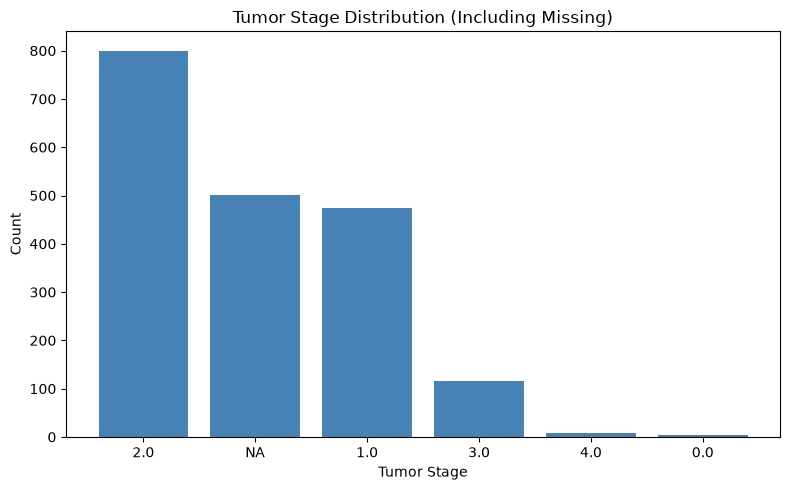

In [10]:
# count including NA/missing values, similar to table(addNA(...))
clinical_stage_counts = clinical_vars["tumor_stage"].value_counts(dropna=False)

labels = [str(x) if pd.notna(x) else "NA" for x in clinical_stage_counts.index]

plt.figure(figsize=(8, 5))
plt.bar(labels, clinical_stage_counts.values, color="steelblue")
plt.title("Tumor Stage Distribution (Including Missing)")
plt.xlabel("Tumor Stage")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [11]:
# Transform categorical variables for modeling
# convert all object (string) columns to category dtype
object_cols = clinical_vars.select_dtypes(include="object").columns
clinical_vars[object_cols] = clinical_vars[object_cols].astype("category")

# Transform numeric categorical variables as factor (category dtype)
cols_to_factor = ["chemotherapy", "hormone_therapy", "radio_therapy", "tumor_stage", "cohort"]
clinical_vars[cols_to_factor] = clinical_vars[cols_to_factor].astype("category")

# categorical variables count after encoding
print(len(clinical_vars.select_dtypes(include="category").columns))


22


# Pre-processing Gene Predictor Variables

In [12]:
gene_vars.head()

,brca1,brca2,palb2,pten,tp53,atm,cdh1,chek2,nbn,nf1,...,srd5a1,srd5a2,srd5a3,st7,star,tnk2,tulp4,ugt2b15,ugt2b17,ugt2b7
0,-1.3990,-0.5738,-1.6217,1.4524,0.3504,1.1517,0.0348,0.1266,-0.8361,-0.8578,...,-1.1877,-0.0194,-1.6345,-0.2142,-0.5698,-1.1741,-1.4779,-0.5954,-0.8847,-0.3354
1,-1.3800,0.2777,-1.2154,0.5296,-0.0136,-0.2659,1.3594,0.7961,0.5419,-2.6059,...,-0.4412,0.4534,0.4068,0.7634,0.0231,0.9121,-0.9538,-0.2264,0.5398,-0.8920
2,0.0670,-0.8426,0.2114,-0.3326,0.5141,-0.0803,1.1398,0.4187,-0.4030,-1.1305,...,-0.5381,0.0668,0.8344,1.7227,0.4024,-3.7172,-1.5538,1.3701,-0.1078,0.3655
3,0.6744,-0.5428,-1.6592,0.6369,1.6708,-0.8880,1.2491,-1.1889,-0.4174,-0.6165,...,-0.5630,-0.7078,0.8228,0.6819,-0.1948,-2.3286,-0.9924,-0.3154,0.2320,-0.4828
4,1.2932,-0.9039,-0.7219,0.2168,0.3484,0.3897,0.9131,0.9356,0.7675,-0.2940,...,-0.5845,-0.3544,-1.0150,2.2961,0.1817,-0.1572,0.0427,5.0048,3.8476,1.3223


# Pre-processing Mutation Predictor Variables

In [13]:
mutation_vars.isna().sum()

pik3ca_mut     0
tp53_mut       0
muc16_mut      0
ahnak2_mut     0
kmt2c_mut      0
              ..
hras_mut       0
prps2_mut      0
smarcb1_mut    0
stmn2_mut      0
siah1_mut      0
Length: 173, dtype: int64

In [14]:
mutation_vars_bin = mutation_vars.apply(
    lambda col: (~(col.astype(str).str.strip().isin(["0", "", "nan", "None"]) | col.isna())).astype(int)
)

mutation_vars_bin

,pik3ca_mut,tp53_mut,muc16_mut,ahnak2_mut,kmt2c_mut,syne1_mut,gata3_mut,map3k1_mut,ahnak_mut,dnah11_mut,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,1,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1900,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1901,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1902,0,0,0,1,0,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,0


# Merging all of the dataframes back together

In [15]:
final_breast_cancer_df = pd.concat([clinical_vars, gene_vars, mutation_vars_bin], axis=1)

final_breast_cancer_df

,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,er_status,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,Positive,...,0,0,0,0,0,0,0,0,0,0
1,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,Positive,...,0,0,0,0,0,0,0,0,0,0
2,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,Positive,...,0,0,0,0,0,0,0,0,0,0
3,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,Positive,...,0,0,0,0,0,0,0,0,0,0
4,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,Positive,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1899,43.10,BREAST CONSERVING,Breast Cancer,Breast Invasive Lobular Carcinoma,High,0,LumA,4.0,Positve,Positive,...,0,0,0,0,0,0,0,0,0,0
1900,42.88,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumB,4.0,Positve,Positive,...,0,0,0,0,0,0,0,0,0,0
1901,62.90,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumB,4.0,Positve,Positive,...,0,0,0,0,0,0,0,0,0,0
1902,61.16,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,Moderate,0,LumB,4.0,Positve,Positive,...,0,0,0,0,0,0,0,0,0,0


# Configurations

In [16]:
RANDOM_STATE = 42

# Splitting data into Training, Validation and Test sets

In [17]:
X = final_breast_cancer_df.drop(columns=['overall_survival_months', 'overall_survival'])
y_structured = Surv.from_dataframe('overall_survival', 'overall_survival_months', final_breast_cancer_df)
X_train, X_test, y_train, y_test = train_test_split(X, y_structured, test_size=0.2, random_state=RANDOM_STATE, stratify=final_breast_cancer_df['overall_survival'])

# Scaling and Transformations

In [18]:
# y_train = y_train.astype(int)
# y_test = y_test.astype(int)

# XGBoost

In [19]:
cat_cols = X_train.select_dtypes(include='category').columns
for col in cat_cols:
    print(col)

type_of_breast_surgery
cancer_type
cancer_type_detailed
cellularity
chemotherapy
pam50_+_claudin-low_subtype
cohort
er_status_measured_by_ihc
er_status
her2_status_measured_by_snp6
her2_status
tumor_other_histologic_subtype
hormone_therapy
inferred_menopausal_state
integrative_cluster
primary_tumor_laterality
oncotree_code
pr_status
radio_therapy
3-gene_classifier_subtype
tumor_stage
death_from_cancer


In [23]:
cat_cols = X_train.select_dtypes(include='category').columns
for col in cat_cols:
    X_train[col] = X_train[col].cat.rename_categories(X_train[col].cat.categories.astype(str))
    X_test[col] = X_test[col].cat.rename_categories(X_test[col].cat.categories.astype(str))

# Encode time + censoring into a single label:
# positive = event occurred at that time, negative = censored at that time
y_train_time = y_train['overall_survival_months']
y_train_event = y_train['overall_survival']
y_train_label = np.where(y_train_event == 1, y_train_time, -y_train_time)

y_test_time = y_test['overall_survival_months']
y_test_event = y_test['overall_survival']
y_test_label = np.where(y_test_event == 1, y_test_time, -y_test_time)

dtrain = xgb.DMatrix(X_train, label=y_train_label, enable_categorical=True)
dtest = xgb.DMatrix(X_test, label=y_test_label, enable_categorical=True)

params = {
    'objective': 'survival:cox',
    'eval_metric': 'cox-nloglik',
    'eta': 0.03,
}

bst = xgb.train(params, dtrain, num_boost_round=171)
risk_scores = bst.predict(dtest)  # higher = higher hazard, shorter survival

c_index = concordance_index(y_test_time, risk_scores, y_test_event)
print(f"C-index: {c_index:.4f}")

C-index: 0.1905


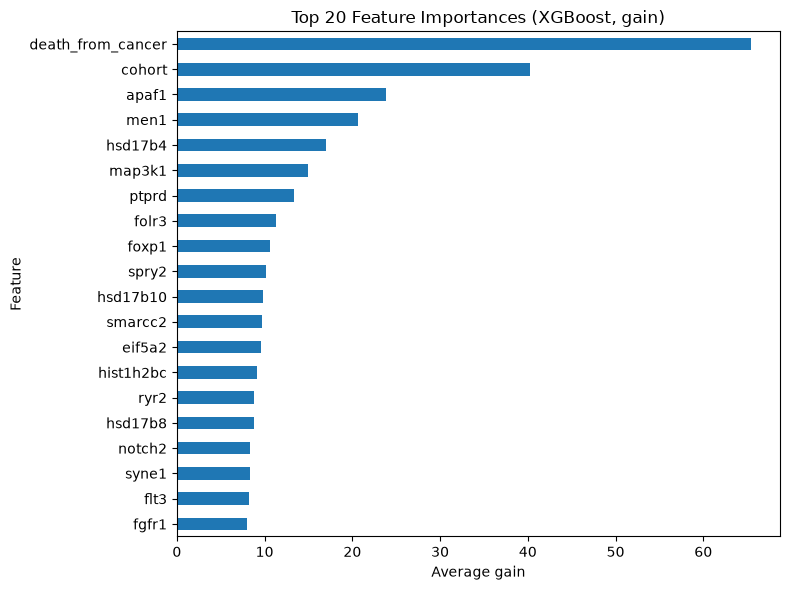

In [24]:
importance_dict = bst.get_score(importance_type='gain')

importances_df = pd.DataFrame(
    {"importance": list(importance_dict.values())},
    index=list(importance_dict.keys()),
).sort_values(by="importance", ascending=False)

top_n = 20
top_features = importances_df.head(top_n)

ax = top_features.plot.barh(
    y="importance",
    figsize=(8, 6),
    legend=False,
)
ax.set_xlabel("Average gain")
ax.set_ylabel("Feature")
ax.set_title(f"Top {top_n} Feature Importances (XGBoost, gain)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Random Forest

In [21]:
rf_model = RandomSurvivalForest(n_estimators=200, random_state=RANDOM_STATE)

cat_cols = X_train.select_dtypes(include='category').columns
num_cols = X_train.select_dtypes(include='number').columns

preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore"), cat_cols)
    ]
)


X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

rf_model.fit(X_train_encoded, y_train)
risk_scores = rf_model.predict(X_test_encoded) 

c_index = concordance_index_censored(
    y_test['overall_survival'],        # event indicator (bool array)
    y_test['overall_survival_months'], # time array
    risk_scores
)

print(f"Concordance Index: {c_index[0]:.4f}")


c:\Users\Harris\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Concordance Index: 0.7891


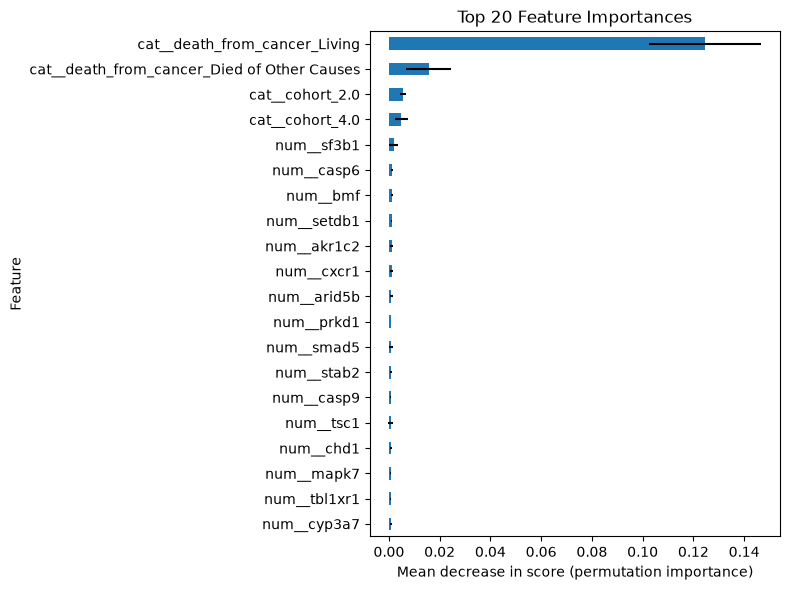

In [22]:
result = permutation_importance(rf_model, X_test_encoded, y_test, random_state=RANDOM_STATE)
importances_df = pd.DataFrame(
    {
        k: result[k]
        for k in (
            "importances_mean",
            "importances_std",
        )
    },
    index=preprocessor.get_feature_names_out(),
).sort_values(by="importances_mean", ascending=False)


top_n = 20
top_features = importances_df.head(top_n)

ax = top_features.plot.barh(
    y="importances_mean",
    xerr="importances_std",
    figsize=(8, 6),
    legend=False,
)
ax.set_xlabel("Mean decrease in score (permutation importance)")
ax.set_ylabel("Feature")
ax.set_title(f"Top {top_n} Feature Importances")
ax.invert_yaxis()  # highest importance at top
plt.tight_layout()
plt.show()

# Kaplan Meier Survival Analysis

            removed  observed  censored  entrance  at_risk
event_at                                                  
0.000000          0         0         0      1523     1523
0.100000          1         0         1         0     1523
0.766667          1         1         0         0     1522
1.233333          1         1         0         0     1521
1.266667          1         1         0         0     1520
...             ...       ...       ...       ...      ...
322.833333        1         1         0         0        5
330.366667        1         1         0         0        4
335.600000        1         0         1         0        3
337.033333        1         1         0         0        2
351.000000        1         0         1         0        1

[1389 rows x 5 columns]


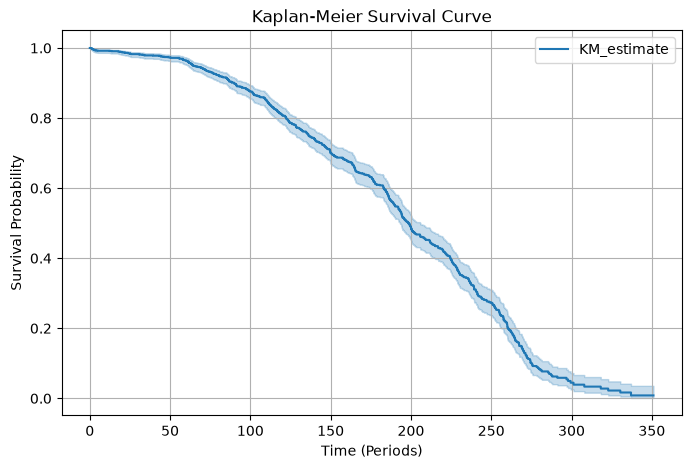

In [27]:
kmf = KaplanMeierFitter()
kmf.fit(
    durations=y_train['overall_survival_months'],
    event_observed=y_train['overall_survival'],
)

print(kmf.event_table)

plt.figure(figsize=(8, 5))
kmf.plot_survival_function()
plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Time (Periods)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()




# Cox Proportional Hazard Model

In [40]:
from sklearn.impute import SimpleImputer

cat_cols = X_train.select_dtypes(include='category').columns
num_cols = X_train.select_dtypes(include='number').columns

for col in num_cols:
    median_val = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_val)
    X_test[col] = X_test[col].fillna(median_val)

# Categorical: convert NaN to a "Missing" string category instead of imputing a guessed value
for col in cat_cols:
    if 'Missing' not in X_train[col].cat.categories:
        X_train[col] = X_train[col].cat.add_categories('Missing')
    if 'Missing' not in X_test[col].cat.categories:
        X_test[col] = X_test[col].cat.add_categories('Missing')
    X_train[col] = X_train[col].fillna('Missing')
    X_test[col] = X_test[col].fillna('Missing')

ordinal_cols = []  # e.g. ['tumor_stage', 'tumor_grade']
nominal_cols = [c for c in cat_cols if c not in ordinal_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('ord', OrdinalEncoder(), ordinal_cols),
        ('nom', OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore"), nominal_cols),
    ]
)

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

cox_prop_haz_model = CoxPHSurvivalAnalysis(ties="efron")
cox_prop_haz_model.fit(X_train_encoded, y_train)

coefficients = pd.Series(cox_prop_haz_model.coef_, index=feature_names)
print("Log Hazard Ratios:\n", coefficients)

prediction = cox_prop_haz_model.predict(X_test_encoded)
c_index = concordance_index_censored(y_test['overall_survival'], y_test['overall_survival_months'], prediction)
print(f"Test Concordance Index: {c_index[0]:.4f}")

c:\Users\Harris\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\Harris\AppData\Local\Programs\Python\Python314\Lib\site-packages\sksurv\linear_model\coxph.py:493: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.828304739250211e-23.
  delta = solve(
c:\Users\Harris\AppData\Local\Programs\Python\Python314\Lib\site-packages\sksurv\linear_model\coxph.py:493: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.679792104866203e-29.
  delta = solve(
c:\Users\Harris\AppData\Local\Programs\Python\Python314\Lib\site-packages\sksurv\linear_model\coxph.py:493: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 1.6865893544441868e-23.
  delta = solve(
c:\Users\Harris\AppData\Local\Programs\Python\Python314\Lib\site-pack

ValueError: search direction contains NaN or infinite values

# PyTorch Survival